<a href="https://colab.research.google.com/github/subha-maker/Marine-Biodiversity-Health-prediction/blob/main/Marine_species.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from google.colab import files  # For file upload

In [ ]:

print("Upload your CSV file:")
uploaded = files.upload()  # This will prompt file upload
file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)
print(f"File {file_name} loaded successfully!\n")

Upload your CSV file:


Saving synthetic_ocean_quality_realistic.csv to synthetic_ocean_quality_realistic.csv
File synthetic_ocean_quality_realistic.csv loaded successfully!



In [ ]:
df = df.fillna(df.mean(numeric_only=True))

In [ ]:
df['score'] = (
    (df['Dissolved_Oxygen'] - df['Dissolved_Oxygen'].min()) /
    (df['Dissolved_Oxygen'].max() - df['Dissolved_Oxygen'].min()) +
    (1 - (df['Turbidity'] - df['Turbidity'].min()) /
     (df['Turbidity'].max() - df['Turbidity'].min())) +
    (1 - (df['Nitrate'] - df['Nitrate'].min()) /
     (df['Nitrate'].max() - df['Nitrate'].min()))
)

In [ ]:
df = df.sort_values('score').reset_index(drop=True)
n = len(df)
df['Health'] = 'Healthy'
df.loc[:int(0.32*n), 'Health'] = 'Poor'
df.loc[int(0.32*n):int(0.65*n), 'Health'] = 'Moderate'

print("Class Distribution:\n", df['Health'].value_counts())

Class Distribution:
 Health
Healthy     34999
Moderate    33001
Poor        32000
Name: count, dtype: int64


In [ ]:
X = df[['Temperature', 'pH', 'Dissolved_Oxygen',
        'Salinity', 'Turbidity', 'Chlorophyll', 'Nitrate']]
y = df['Health']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [ ]:
imputer = SimpleImputer(strategy='median')
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42),
    "SVM": SVC(kernel='rbf', C=5, gamma='scale', probability=True, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=7)
}

results = {}
cv_scores = {}

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=skf, scoring='accuracy')
    cv_scores[name] = scores
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    print(f"\n{name} - Test Accuracy: {round(acc, 3)}")
    print("Cross-Validation Accuracy: ", np.round(scores.mean(), 3), "±", np.round(scores.std(), 3))
    print(classification_report(y_test, y_pred))


Random Forest - Test Accuracy: 0.904
Cross-Validation Accuracy:  0.902 ± 0.004
              precision    recall  f1-score   support

     Healthy       0.92      0.94      0.93      7000
    Moderate       0.86      0.85      0.85      6600
        Poor       0.94      0.92      0.93      6400

    accuracy                           0.90     20000
   macro avg       0.90      0.90      0.90     20000
weighted avg       0.90      0.90      0.90     20000


SVM - Test Accuracy: 0.991
Cross-Validation Accuracy:  0.992 ± 0.0
              precision    recall  f1-score   support

     Healthy       0.99      0.99      0.99      7000
    Moderate       0.98      0.99      0.99      6600
        Poor       0.99      0.99      0.99      6400

    accuracy                           0.99     20000
   macro avg       0.99      0.99      0.99     20000
weighted avg       0.99      0.99      0.99     20000


KNN - Test Accuracy: 0.92
Cross-Validation Accuracy:  0.918 ± 0.002
              precisi

In [ ]:
best_model_name = max(results, key=results.get)
best_model = models[best_model_name]

print("\n Best Model:", best_model_name)
print("Best Test Accuracy:", round(results[best_model_name], 3))


 Best Model: SVM
Best Test Accuracy: 0.991


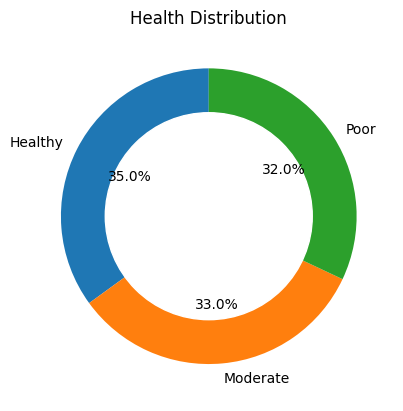

In [ ]:
counts = df['Health'].value_counts()
plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90)
circle = plt.Circle((0,0),0.7,color='white')
plt.gca().add_artist(circle)
plt.title("Health Distribution")
plt.show()

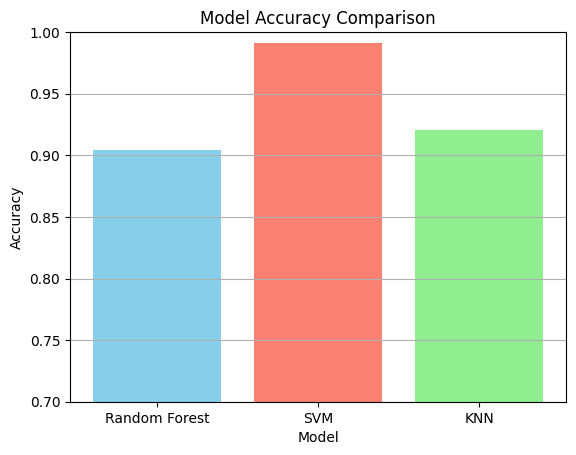

In [ ]:
plt.bar(list(results.keys()), list(results.values()), color=['skyblue', 'salmon', 'lightgreen'])
plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0.7,1.0)
plt.grid(axis='y')
plt.show()

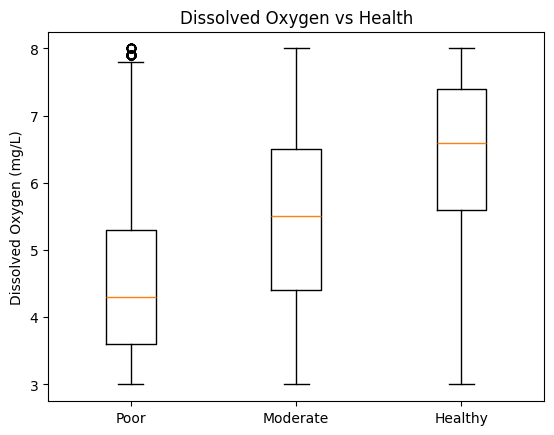

In [ ]:
plt.boxplot([
    df[df['Health']=='Poor']['Dissolved_Oxygen'],
    df[df['Health']=='Moderate']['Dissolved_Oxygen'],
    df[df['Health']=='Healthy']['Dissolved_Oxygen']
], tick_labels=['Poor','Moderate','Healthy'])  # ✅ changed here

plt.title("Dissolved Oxygen vs Health")
plt.ylabel("Dissolved Oxygen (mg/L)")
plt.show()

In [ ]:
new_data = pd.DataFrame({
    'Temperature':[29],
    'pH':[7.4],
    'Dissolved_Oxygen':[5.2],
    'Salinity':[31],
    'Turbidity':[7],
    'Chlorophyll':[2.1],
    'Nitrate':[1.2]
})

new_data = scaler.transform(imputer.transform(new_data))
prediction = best_model.predict(new_data)
print("\nPrediction for new data:", prediction[0])


Prediction for new data: Poor


In [ ]:
new_data = pd.DataFrame({
    'Temperature':[29],
    'pH':[7.4],
    'Dissolved_Oxygen':[7.2],
    'Salinity':[31],
    'Turbidity':[5],
    'Chlorophyll':[2.1],
    'Nitrate':[1.2]
})

new_data = scaler.transform(imputer.transform(new_data))
prediction = best_model.predict(new_data)
print("\nPrediction for new data:", prediction[0])


Prediction for new data: Moderate


In [ ]:
new_data = pd.DataFrame({
    'Temperature':[28],
    'pH':[7.4],
    'Dissolved_Oxygen':[8.2],
    'Salinity':[31],
    'Turbidity':[2],
    'Chlorophyll':[2.1],
    'Nitrate':[1.2]
})

new_data = scaler.transform(imputer.transform(new_data))
prediction = best_model.predict(new_data)
print("\nPrediction for new data:", prediction[0])


Prediction for new data: Healthy
